<a href="https://colab.research.google.com/github/ManviGumber08/comp3132/blob/main/LabWeek9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LabWeek9: Prevent Overfitting - Part I

## Importing Dataset: IMDB

In [1]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Note:** We first encountered this dataset in `LabWeek5`. You can refer to that notebook for clarification on the text-to-numbers decoding process. Through vectorizing process we turn text data into vectors.

**Perform some sanity checks on the dataset:** For example, find the `shape` of the dataset and print samples to make sense of the data.

In [2]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Print a sample review (vectorized)
print("\nSample vectorized review (first 10 values):", x_train[0][:10])
print("Corresponding label:", y_train[0])

# Decoding a review back to words
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])

print("\nDecoded sample review:")
print(decoded_review)

Shape of x_train: (25000, 10000)
Shape of x_test: (25000, 10000)
Shape of y_train: (25000,)
Shape of y_test: (25000,)

Sample vectorized review (first 10 values): [0. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
Corresponding label: 1.0
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Decoded sample review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy

## Fighting overfitting -  Reducing the network's size


The general workflow to find an appropriate model size is to start with relatively few layers and
parameters, and start increasing the size of the layers or adding new layers until you see diminishing returns with regard to the
validation loss.



**Note:** we use `test set` as our `validation set`.

**Complete the following code for `original model` architecture**

In [3]:
from keras import models
from keras import layers

original_model = models.Sequential()
original_model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
#TODO: add one hidden layer with 16 units with proper activation function

#TODO: add the output layer. Remember our task is binary classificaion, whether a review is 0:negative or 1:positive.

original_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
original_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │         160,016 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,016 (625.06 KB)

 Trainable params: 160,016 (625.06 KB)

 Non-trainable params: 0 (0.00 B)

**Define another model with fewer parameters. 4 units in each hidden layer.**

In [7]:
smaller_model = models.Sequential()
#TODO: add hidden/ouput layers and compile the smaller model
# Define the smaller model
smaller_model = models.Sequential()
smaller_model.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
smaller_model.add(layers.Dense(4, activation='relu'))  # Second hidden layer
smaller_model.add(layers.Dense(1, activation='sigmoid'))  # Output layer

# Compile the smaller model
smaller_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['acc'])

# Print model summary
smaller_model.summary()



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 4)                   │          40,004 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,029 (156.36 KB)

 Trainable params: 40,029 (156.36 KB)

 Non-trainable params: 0 (0.00 B)


**Train (1) original_model and (2) smaller_model seperately for `epochs=20` and `batch_size=512`. Also pass `x_test` and `y_test` as `validation_data`.**

In [8]:
#TODO: your code here for training original_model

# Train original model
original_hist = original_model.fit(x_train, y_train,
                                   epochs=20,
                                   batch_size=512,
                                   validation_data=(x_test, y_test))

# Train smaller model
smaller_hist = smaller_model.fit(x_train, y_train,
                                 epochs=20,
                                 batch_size=512,
                                 validation_data=(x_test, y_test))


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - acc: 0.7398 - loss: 0.5588 - val_acc: 0.8477 - val_loss: 0.3742
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9021 - loss: 0.2839 - val_acc: 0.8850 - val_loss: 0.2919
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9239 - loss: 0.2151 - val_acc: 0.8843 - val_loss: 0.2869
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.9367 - loss: 0.1783 - val_acc: 0.8737 - val_loss: 0.3177
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.9460 - loss: 0.1533 - val_acc: 0.8833 - val_loss: 0.2984
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - acc: 0.9536 - loss: 0.1340 - val_acc: 0.8788 - val_loss: 0.3190
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.9569 - loss: 0.1231 - val_acc: 0.8754 - val_loss: 0.3395
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.9670 - loss: 0.1019 - val_acc: 0.8667 - val_loss: 0.3787
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.9698

In [9]:

# Train original model
original_hist = original_model.fit(x_train, y_train,
                                   epochs=20,
                                   batch_size=512,
                                   validation_data=(x_test, y_test))

# Train smaller model
smaller_hist = smaller_model.fit(x_train, y_train,
                                 epochs=20,
                                 batch_size=512,
                                 validation_data=(x_test, y_test))


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - acc: 0.9945 - loss: 0.0221 - val_acc: 0.8561 - val_loss: 0.6921
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.9970 - loss: 0.0161 - val_acc: 0.8570 - val_loss: 0.6954
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.9979 - loss: 0.0121 - val_acc: 0.8538 - val_loss: 0.7243
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.9981 - loss: 0.0112 - val_acc: 0.8571 - val_loss: 0.7580
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9977 - loss: 0.0115 - val_acc: 0.8551 - val_loss: 0.7804
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - acc: 0.9975 - loss: 0.0112 - val_acc: 0.8562 - val_loss: 0.8143
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - acc: 0.9983 - loss: 0.0084 - val_acc: 0.8546 - val_loss: 0.8301
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.9984 - loss: 0.0075 - val_acc: 0.8560 - val_loss: 0.8555
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.9989

**`orginal_hist` and `smaller_hist` are `objects` returned after training the models.**
- We can get access to the `history` attribute of `origial_hist` object through dot operator.
- TODO: The history attribute is a data structure of type `dictionary` containing data about everything that happened during training. Show the `keys` of this `dictionary`.

In [10]:
print(original_hist.history)
#TODO: print out the keys of the output dictionary
#your code here
# Print the keys of the training history dictionary
print(original_hist.history.keys())



{'acc': [0.9940800070762634, 0.9951199889183044, 0.9962800145149231, 0.9971200227737427, 0.9974799752235413, 0.9970800280570984, 0.9975200295448303, 0.9972800016403198, 0.9976400136947632, 0.9972400069236755, 0.9990000128746033, 0.9995999932289124, 0.9984400272369385, 0.9979199767112732, 0.9988800287246704, 0.9986400008201599, 0.9986000061035156, 0.9987199902534485, 1.0, 0.9987999796867371], 'loss': [0.022936319932341576, 0.020447565242648125, 0.015510565601289272, 0.013710403814911842, 0.01202373020350933, 0.012370537966489792, 0.010473414324223995, 0.010457484982907772, 0.009348559193313122, 0.010897140949964523, 0.004953157622367144, 0.002949652960523963, 0.006412451155483723, 0.007781748194247484, 0.004400713834911585, 0.005355046596378088, 0.004477589391171932, 0.004872264806181192, 0.0008982060826383531, 0.0042690434493124485], 'val_acc': [0.8560799956321716, 0.8569999933242798, 0.8537999987602234, 0.8571199774742126, 0.8551200032234192, 0.8562399744987488, 0.854640007019043, 0.8

**Plot `val_loss` vs. epochs for both models in one plot**

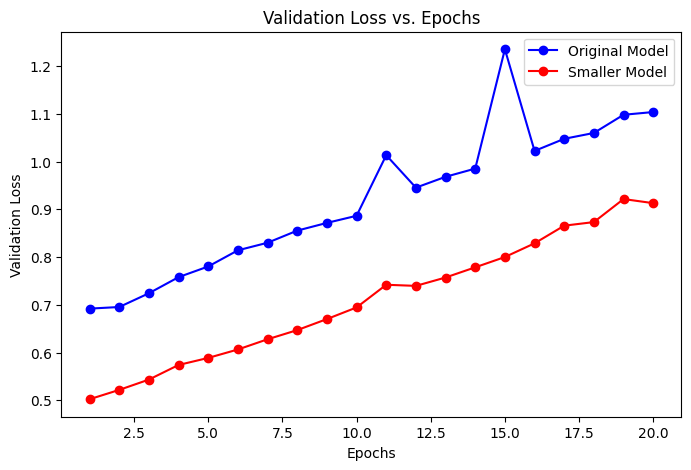

In [11]:
from matplotlib import pyplot as plt
#TODO: your code here


# Extract loss values
epochs = range(1, 21)  # Since we trained for 20 epochs
original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, original_val_loss, 'bo-', label='Original Model')  # 'bo-' = blue dots
plt.plot(epochs, smaller_val_loss, 'ro-', label='Smaller Model')  # 'ro-' = red dots
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs. Epochs')
plt.legend()
plt.show()


**Plot training `loss` vs. epochs for both models in one plot**

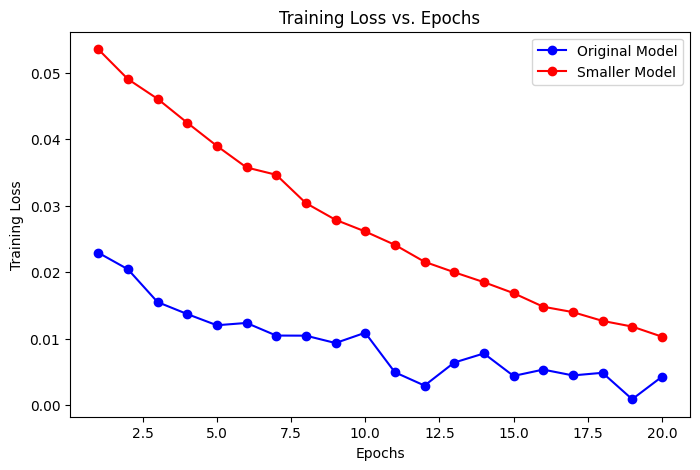

In [12]:
#TODO: your code hereß
# Extract training loss values
original_train_loss = original_hist.history['loss']
smaller_train_loss = smaller_hist.history['loss']

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, original_train_loss, 'bo-', label='Original Model')
plt.plot(epochs, smaller_train_loss, 'ro-', label='Smaller Model')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epochs')
plt.legend()
plt.show()


**Questions:** Which model overfits earlier? How can you see the size of the model on overfitting?

**Answer:** TODO

**Now define a very large model (e.g., with 512 units in hidden layer) and compare the `loss` and `val_loss` of this big model and the `original model` and `smaller_model`.**

In [14]:
#your code here

**Discuss the results**

**Answer:** TODO

## Fighting overfitting - Adding weight regularization


A common way to mitigate overfitting is to put constraints on the complexity
of a network by forcing its weights to only take small values. This is called
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments.


**Complere the model below**

In [15]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu', input_shape=(10000,)))

#TODO: Add a dense layer with 16 unuts with L2 regularization

l2_model.add(layers.Dense(1, activation='sigmoid'))

In [16]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training
than at test time.



**Train the model with regularization and compare the validation loss between this model and the `original_model` and `smaller model`.**

In [25]:
from sklearn.model_selection import train_test_split

# Assuming x_train, y_train are already loaded
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


In [ ]:
large_hist = large_model.fit(x_train, y_train,
                             epochs=20,
                             batch_size=512,
                             validation_data=(x_val, y_val))



Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 310ms/step - acc: 0.6609 - loss: 0.6268 - val_acc: 0.8620 - val_loss: 0.3351
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - acc: 0.8800 - loss: 0.3050 - val_acc: 0.8570 - val_loss: 0.3348
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 292ms/step - acc: 0.9062 - loss: 0.2345 - val_acc: 0.8870 - val_loss: 0.2700
Epoch 4/20
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - acc: 0.9370 - loss: 0.1655

In [21]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu', input_shape=(10000,)))

# TODO: Add a dense layer with 16 units with L2 regularization
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))

l2_model.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])


**Note:** As alternatives to L2 regularization, you could use one of the following Keras weight regularizers:

In [20]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization at the same time
regularizers.l1_l2(l1=0.001, l2=0.001)

## Recap

To recap: here the most common ways to prevent overfitting in neural networks:

* Getting more training data.
* Reducing the capacity of the network.
* Adding weight regularization.
* Adding dropout. (next session)

**Observation 1:** The bigger network gets its training loss near zero very quickly. The more capacity the network has, the quicker it will be
able to model the training data (resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a large
difference between the training and validation loss).

**Observation 2:** The model with L2 regularization has become much more resistant to overfitting than the reference model,
even though both models have the same number of parameters.

In [ ]:
# Train the L2 regularized model
l2_hist = l2_model.fit(x_train, y_train,
                        epochs=20,
                        batch_size=512,
                        validation_data=(x_val, y_val))

# Plot validation loss comparison
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), original_hist.history['val_loss'], 'bo-', label='Original Model')
plt.plot(range(1, 21), smaller_hist.history['val_loss'], 'ro-', label='Smaller Model')
plt.plot(range(1, 21), l2_hist.history['val_loss'], 'go-', label='L2 Regularized Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Comparison of Validation Loss')
plt.legend()
plt.show()


In [ ]:
# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization (Elastic Net)
regularizers.l1_l2(l1=0.001, l2=0.001)
